<a href="https://colab.research.google.com/github/Ramank510/CMP7005--Beijing-Air-Quality-Analysis/blob/main/CMP7005_PRAC1_S2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMP7005 — Programming for Data Analysis
## PRAC1
### Beijing Air Quality Analysis (2013–2017)
---
**Module:** CMP7005 | **Semester:** 2 | **Year:** 2025–2026

**Stations selected:** Dongsi, Guanyuan (Urban) | Dingling, Huairou (Suburban)

---

### Installing the libraries

In [ ]:
# Install Streamlit
!pip install -q streamlit

# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle
import zipfile

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Settings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
sns.set_style('whitegrid')

# Create folders
os.makedirs('data', exist_ok=True)
os.makedirs('figures', exist_ok=True)

print('✅ All libraries imported!')
print('✅ Folders created!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 43.2 MB/s eta 0:00:00
✅ All libraries imported!
✅ Folders created!


---
## Uploading the  Data


In [ ]:
# Upload all the datasets (zip file)
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    os.rename(filename, f'data/{filename}')
    print(f'✅ Uploaded: {filename}')

Saving Assessment Data-20260306.zip to Assessment Data-20260306.zip
✅ Uploaded: Assessment Data-20260306.zip


In [ ]:
# Extract the zip file
with zipfile.ZipFile('data/Assessment Data-20260306.zip', 'r') as zip_ref:
    zip_ref.extractall('data/')

print('✅ Zip extracted!')
print('\nCSV files available:')
for f in sorted(os.listdir('data/')):
    if f.endswith('.csv'):
        print(f'  - {f}')

✅ Zip extracted!

CSV files available:
  - PRSA_Data_Aotizhongxin_20130301-20170228.csv
  - PRSA_Data_Changping_20130301-20170228.csv
  - PRSA_Data_Dingling_20130301-20170228.csv
  - PRSA_Data_Dongsi_20130301-20170228.csv
  - PRSA_Data_Guanyuan_20130301-20170228.csv
  - PRSA_Data_Gucheng_20130301-20170228.csv
  - PRSA_Data_Huairou_20130301-20170228.csv
  - PRSA_Data_Nongzhanguan_20130301-20170228.csv
  - PRSA_Data_Shunyi_20130301-20170228.csv
  - PRSA_Data_Tiantan_20130301-20170228.csv
  - PRSA_Data_Wanliu_20130301-20170228.csv
  - PRSA_Data_Wanshouxigong_20130301-20170228.csv


---
## 1. Data Selection & Handling


### Station Selection Justification
Four stations were selected based on Xu & Zhang (2004) and Yao et al. (2015):

| Station | Type | Reason |
|---------|------|--------|
| Dongsi | Urban | Central Beijing, Dongcheng district — high traffic, high population density |
| Guanyuan | Urban | Xicheng district, inner city — near major roads and commercial activity |
| Dingling | Suburban | Changping district, north Beijing — semi-rural, near Ming Tombs |
| Huairou | Suburban | Huairou district, northernmost — mountainous, semi-rural, low industrial activity |

In [ ]:
# Load 4 selected station CSV files
selected_stations = ['Dongsi', 'Guanyuan', 'Dingling', 'Huairou']
dataframes = []

for station in selected_stations:
    filepath = f'data/PRSA_Data_{station}_20130301-20170228.csv'
    df = pd.read_csv(filepath)
    print(f'✅ Loaded {station}: {df.shape[0]:,} rows, {df.shape[1]} columns')
    dataframes.append(df)

# Merge into one combined dataset
combined_df = pd.concat(dataframes, ignore_index=True)

# Create datetime column
combined_df['datetime'] = pd.to_datetime(combined_df[['year', 'month', 'day', 'hour']])

# Save combined dataset
combined_df.to_csv('data/combined_dataset.csv', index=False)

print(f'\n✅ Combined dataset: {combined_df.shape[0]:,} rows x {combined_df.shape[1]} columns')
print(f'📅 Date range: {combined_df["datetime"].min().date()} to {combined_df["datetime"].max().date()}')
print(f'🏙️  Stations: {list(combined_df["station"].unique())}')

✅ Loaded Dongsi: 35,064 rows, 18 columns
✅ Loaded Guanyuan: 35,064 rows, 18 columns
✅ Loaded Dingling: 35,064 rows, 18 columns
✅ Loaded Huairou: 35,064 rows, 18 columns

✅ Combined dataset: 140,256 rows x 19 columns
📅 Date range: 2013-03-01 to 2017-02-28
🏙️  Stations: ['Dongsi', 'Guanyuan', 'Dingling', 'Huairou']


---
## 2. Exploratory Data Analysis (EDA)


### 2.1 Data Understanding


In [ ]:
# Dataset overview
print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Rows    : {combined_df.shape[0]:,}')
print(f'Columns : {combined_df.shape[1]}')
print(f'\nColumn Names:')
for col in combined_df.columns:
    print(f'  - {col}')

DATASET OVERVIEW
Rows    : 140,256
Columns : 19

Column Names:
  - No
  - year
  - month
  - day
  - hour
  - PM2.5
  - PM10
  - SO2
  - NO2
  - CO
  - O3
  - TEMP
  - PRES
  - DEWP
  - RAIN
  - wd
  - WSPM
  - station
  - datetime


In [ ]:
# Data types and missing values
print('=' * 50)
print('DATA TYPES & MISSING VALUES')
print('=' * 50)

info_df = pd.DataFrame({
    'Column'    : combined_df.columns,
    'Data Type' : combined_df.dtypes.values,
    'Missing'   : combined_df.isnull().sum().values,
    'Missing %' : (combined_df.isnull().sum().values / len(combined_df) * 100).round(2)
})
print(info_df.to_string(index=False))

DATA TYPES & MISSING VALUES
  Column      Data Type  Missing  Missing %
      No          int64        0       0.00
    year          int64        0       0.00
   month          int64        0       0.00
     day          int64        0       0.00
    hour          int64        0       0.00
   PM2.5        float64     3098       2.21
    PM10        float64     2415       1.72
     SO2        float64     2847       2.03
     NO2        float64     5133       3.66
      CO        float64     8384       5.98
      O3        float64     4202       3.00
    TEMP        float64      144       0.10
    PRES        float64      143       0.10
    DEWP        float64      146       0.10
    RAIN        float64      146       0.10
      wd         object      601       0.43
    WSPM        float64      120       0.09
 station         object        0       0.00
datetime datetime64[ns]        0       0.00


In [ ]:
# Statistical summary
print('=' * 50)
print('STATISTICAL SUMMARY')
print('=' * 50)

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

combined_df[numeric_cols].describe().round(2)

STATISTICAL SUMMARY


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,137158.00,137841.00,137409.00,135123.00,131872.00,136054.00,140112.00,140113.00,140110.00,140110.00,140136.00
mean,76.20,98.68,15.01,42.99,1130.21,60.33,13.35,1009.94,2.33,0.06,1.77
std,78.49,89.20,20.73,33.46,1061.42,56.21,11.51,10.48,13.86,0.83,1.25
min,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00
25%,19.00,32.00,2.00,17.00,400.00,16.00,3.00,1001.50,-9.20,0.00,0.90
50%,51.00,76.00,7.00,35.00,800.00,50.00,14.30,1009.50,2.90,0.00,1.40
75%,107.00,138.00,19.00,61.00,1400.00,84.00,23.10,1018.10,15.00,0.00,2.20
max,881.00,999.00,315.00,270.00,10000.00,1071.00,41.40,1042.00,29.10,72.50,12.90


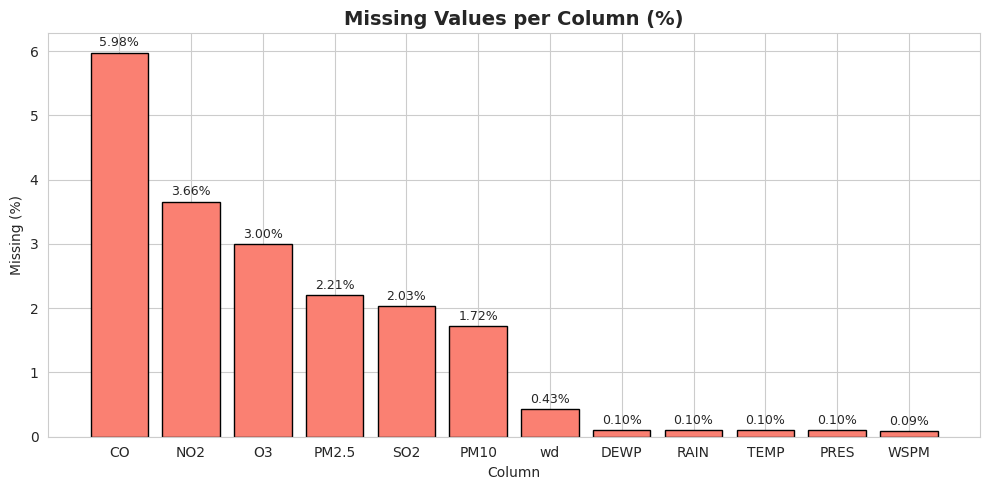

✅ Chart saved!


In [ ]:
# Missing values chart
missing_pct = (combined_df.isnull().sum() / len(combined_df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(missing_pct.index, missing_pct.values, color='salmon', edgecolor='black')

for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_title('Missing Values per Column (%)', fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing (%)')
plt.tight_layout()
plt.savefig('figures/missing_values.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**Initial Observations:**
- Combined dataset has **140,256 hourly records** across 4 years (March 2013 – February 2017)
- **CO has the most missing data (5.98%)** — likely due to sensor faults at some stations
- **Weather variables (TEMP, PRES, DEWP, RAIN) have very low missing rates (<0.10%)** — reliable sensors
- **PM2.5 mean (76.2 µg/m³) is over 5x the WHO guideline of 15 µg/m³** — serious air quality problem
- **PM2.5 max of 881 µg/m³** shows extreme pollution episodes exist in the data

### 2.2 Data Preprocessing


In [ ]:
# Removing the duplicate rows
before = combined_df.shape[0]
combined_df.drop_duplicates(inplace=True)
after = combined_df.shape[0]

print(f'Rows before : {before:,}')
print(f'Rows after  : {after:,}')
print(f'Duplicates removed: {before - after}')

Rows before : 140,256
Rows after  : 140,256
Duplicates removed: 0


In [ ]:
# Handling the missing values using forward fill + backward fill
# We sort by station and time first to ensure correct temporal order
# Forward fill uses the last reading to fill the gap and backward fill uses the current reading to fill the previous gap
# This is appropriate for air quality data as values change gradually

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

combined_df = combined_df.sort_values(['station', 'datetime']).reset_index(drop=True)

combined_df[numeric_cols] = combined_df.groupby('station')[numeric_cols].transform(
    lambda x: x.ffill().bfill()
)

combined_df['wd'] = combined_df.groupby('station')['wd'].transform(
    lambda x: x.fillna(x.mode()[0])
)

print('Missing values after filling:')
print(combined_df[numeric_cols].isnull().sum())
print(f'\n✅ Total missing values remaining: {combined_df.isnull().sum().sum()}')

Missing values after filling:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64

✅ Total missing values remaining: 0


In [ ]:
#create new useful columns

# Season based on month
season_map = {
    12:'Winter', 1:'Winter',  2:'Winter',
    3:'Spring',  4:'Spring',  5:'Spring',
    6:'Summer',  7:'Summer',  8:'Summer',
    9:'Autumn', 10:'Autumn', 11:'Autumn'
}
combined_df['season'] = combined_df['month'].map(season_map)

# Station type
combined_df['station_type'] = combined_df['station'].map({
    'Dongsi':'Urban', 'Guanyuan':'Urban',
    'Dingling':'Suburban', 'Huairou':'Suburban'
})

# Day of week and weekend
combined_df['day_of_week'] = combined_df['datetime'].dt.dayofweek
combined_df['is_weekend']  = combined_df['day_of_week'].isin([5, 6]).astype(int)

# AQI Category based on US EPA PM2.5 breakpoints
def aqi_category(pm25):
    if pm25 <= 12:    return '1-Good'
    elif pm25 <= 35:  return '2-Moderate'
    elif pm25 <= 55:  return '3-Unhealthy (Sensitive)'
    elif pm25 <= 150: return '4-Unhealthy'
    elif pm25 <= 250: return '5-Very Unhealthy'
    else:             return '6-Hazardous'

combined_df['AQI_Category'] = combined_df['PM2.5'].apply(aqi_category)

# Station encoded as number for machine learning
le = LabelEncoder()
combined_df['station_encoded'] = le.fit_transform(combined_df['station'])

print('✅ Feature engineering complete!')
print('\nSeason counts:')
print(combined_df['season'].value_counts())
print('\nAQI Category counts:')
print(combined_df['AQI_Category'].value_counts())

✅ Feature engineering complete!

Season counts:
season
Spring    35328
Summer    35328
Autumn    34944
Winter    34656
Name: count, dtype: int64

AQI Category counts:
AQI_Category
4-Unhealthy                46941
2-Moderate                 31837
1-Good                     23470
3-Unhealthy (Sensitive)    18043
5-Very Unhealthy           14176
6-Hazardous                 5789
Name: count, dtype: int64


In [ ]:
# Step 4: Lag Features — capture temporal dependency in pollution
# If PM2.5 was high 1 hour ago, it is likely still high now
# This is a standard technique in time-series analysis

combined_df['PM2.5_lag1']  = combined_df.groupby('station')['PM2.5'].shift(1)   # 1 hour ago
combined_df['PM2.5_lag24'] = combined_df.groupby('station')['PM2.5'].shift(24)  # 24 hours ago
combined_df['Temp_x_Wspd'] = combined_df['TEMP'] * combined_df['WSPM']          # interaction feature

print('✅ Lag features created!')
print(f'Missing in lag1  : {combined_df["PM2.5_lag1"].isnull().sum()}')
print(f'Missing in lag24 : {combined_df["PM2.5_lag24"].isnull().sum()}')

✅ Lag features created!
Missing in lag1  : 4
Missing in lag24 : 96


In [ ]:
# Save cleaned dataset
combined_df.to_csv('data/cleaned_dataset.csv', index=False)

print('✅ Cleaned dataset saved!')
print(f'Final shape: {combined_df.shape[0]:,} rows x {combined_df.shape[1]} columns')

✅ Cleaned dataset saved!
Final shape: 140,256 rows x 28 columns


### 2.3 Statistical Analysis & Visualisation


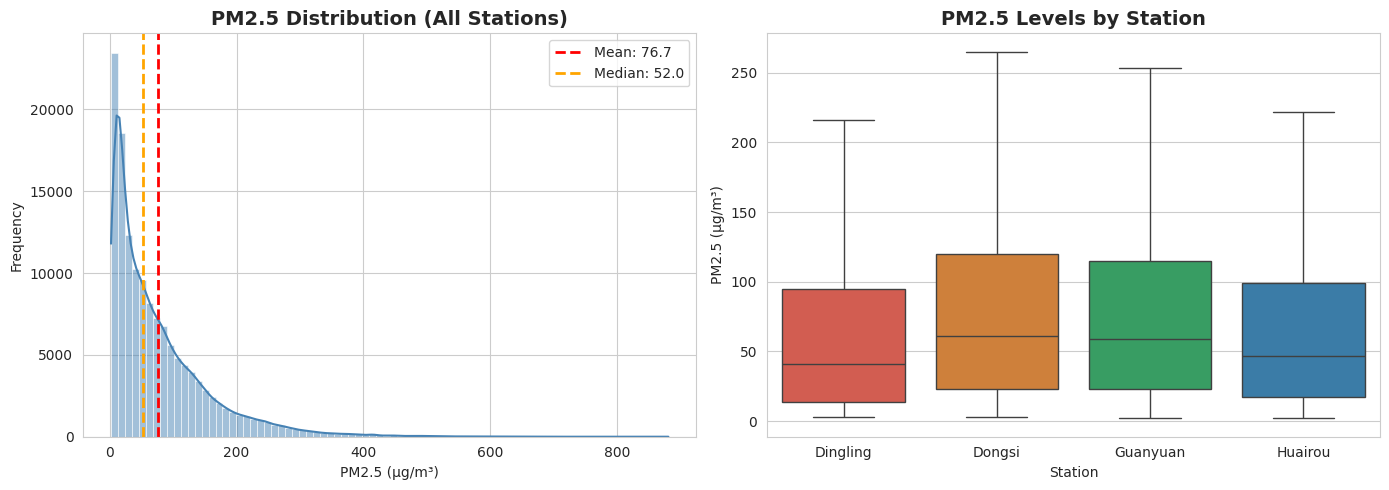

✅ Chart saved!


In [ ]:
# Colour map used consistently across all charts
colors_map = {
    'Dongsi':'#e74c3c', 'Guanyuan':'#e67e22',
    'Dingling':'#27ae60', 'Huairou':'#2980b9'
}

# Chart 1: PM2.5 Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(combined_df['PM2.5'], bins=80, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(combined_df['PM2.5'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {combined_df['PM2.5'].mean():.1f}")
axes[0].axvline(combined_df['PM2.5'].median(), color='orange', linestyle='--', linewidth=2,
                label=f"Median: {combined_df['PM2.5'].median():.1f}")
axes[0].set_title('PM2.5 Distribution (All Stations)', fontweight='bold')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

sns.boxplot(x='station', y='PM2.5', data=combined_df,
            palette=['#e74c3c','#e67e22','#27ae60','#2980b9'],
            ax=axes[1], showfliers=False)
axes[1].set_title('PM2.5 Levels by Station', fontweight='bold')
axes[1].set_xlabel('Station')
axes[1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.savefig('figures/pm25_distribution.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**observastion:** The PM2.5 distribution is strongly right-skewed — the mean (76.7) is much higher than the median (52.0), showing that frequent extreme pollution episodes pull the average up. Urban stations (Dongsi, Guanyuan) consistently show higher PM2.5 than suburban stations (Dingling, Huairou), confirming the urban-rural pollution gradient driven by higher traffic and industrial activity in central Beijing.

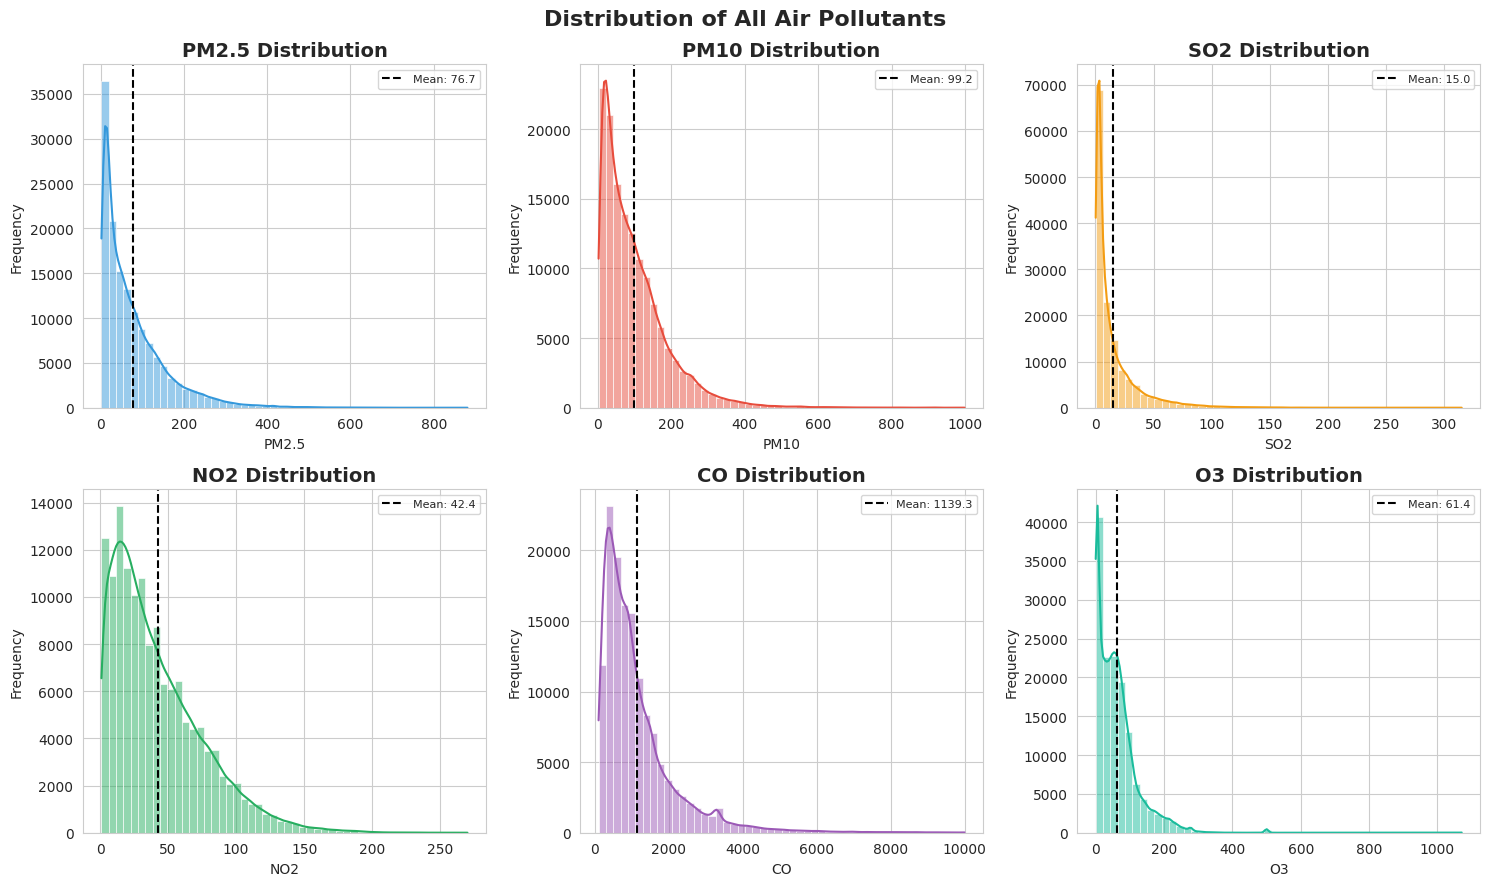

✅ Chart saved!


In [ ]:
# Chart 2: All Pollutant Distributions
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
colors = ['#3498db', '#e74c3c', '#f39c12', '#27ae60', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(pollutants, colors)):
    sns.histplot(combined_df[col], bins=50, kde=True, color=color, ax=axes[i])
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(combined_df[col].mean(), color='black', linestyle='--',
                    linewidth=1.5, label=f"Mean: {combined_df[col].mean():.1f}")
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of All Air Pollutants', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/pollutant_distributions.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**Observation:** All pollutants show right-skewed distributions typical of air quality data. CO has the most extreme skew with a mean of 1,139 µg/m³ due to combustion events. O3 is notably more symmetric — it is not directly emitted but formed photochemically from sunlight, producing a different distribution pattern compared to the other pollutants.

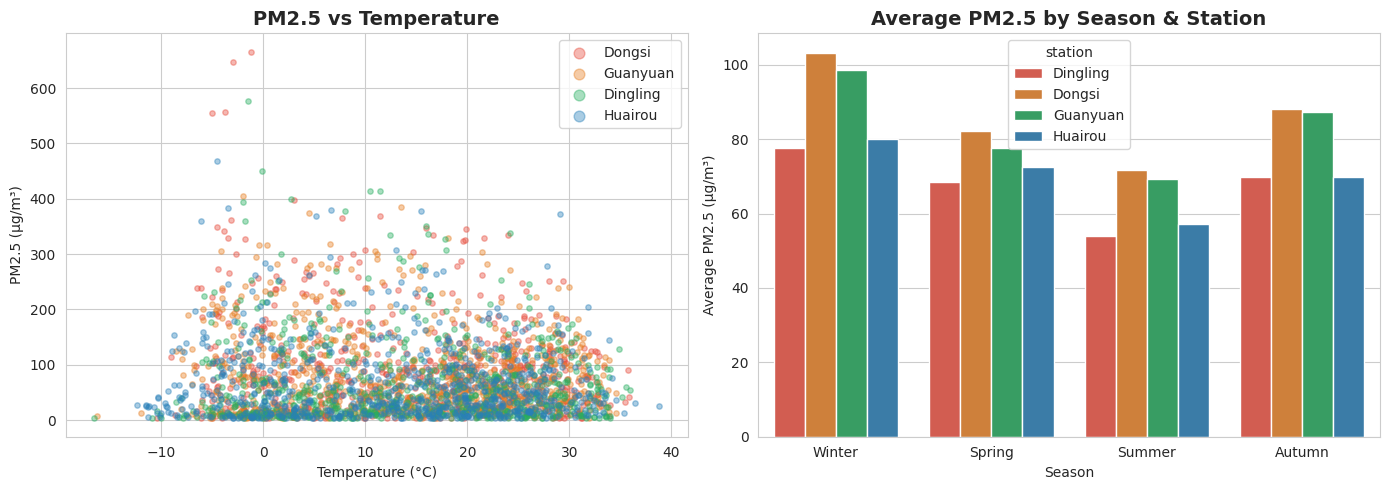

✅ Chart saved!


In [ ]:
# Chart 3: PM2.5 vs Temperature and Seasonal Patterns
sample = combined_df.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for station, color in colors_map.items():
    mask = sample['station'] == station
    axes[0].scatter(sample.loc[mask, 'TEMP'], sample.loc[mask, 'PM2.5'],
                    alpha=0.4, s=15, label=station, color=color)
axes[0].set_title('PM2.5 vs Temperature', fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend(markerscale=2)

season_avg = combined_df.groupby(['season', 'station'])['PM2.5'].mean().reset_index()
sns.barplot(x='season', y='PM2.5', hue='station', data=season_avg,
            order=['Winter','Spring','Summer','Autumn'], ax=axes[1],
            palette=['#e74c3c','#e67e22','#27ae60','#2980b9'])
axes[1].set_title('Average PM2.5 by Season & Station', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Average PM2.5 (µg/m³)')

plt.tight_layout()
plt.savefig('figures/pm25_temp_season.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**Observation**: There is a clear negative relationship between temperature and PM2.5 — highest pollution clusters at cold temperatures (below 5°C). This is driven by two factors: (1) coal-burning for heating in winter increases direct emissions, and (2) temperature inversions trap pollutants near the surface. Winter produces the highest PM2.5 across all stations, while summer is the cleanest season due to monsoon rainfall. Urban stations consistently exceed suburban stations in every season.

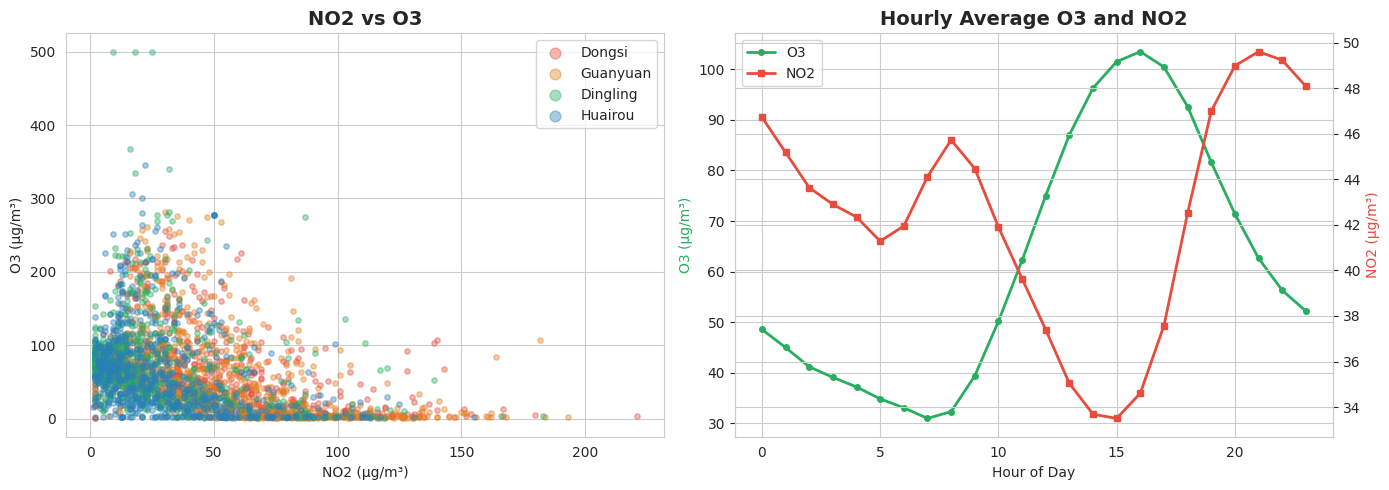

✅ Chart saved!


In [ ]:
# Chart 4: NO2 vs O3
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for station, color in colors_map.items():
    mask = sample['station'] == station
    axes[0].scatter(sample.loc[mask, 'NO2'], sample.loc[mask, 'O3'],
                    alpha=0.4, s=15, label=station, color=color)
axes[0].set_title('NO2 vs O3', fontweight='bold')
axes[0].set_xlabel('NO2 (µg/m³)')
axes[0].set_ylabel('O3 (µg/m³)')
axes[0].legend(markerscale=2)

hourly_o3  = combined_df.groupby('hour')['O3'].mean()
hourly_no2 = combined_df.groupby('hour')['NO2'].mean()
ax_left  = axes[1]
ax_right = ax_left.twinx()
ax_left.plot(hourly_o3.index, hourly_o3.values, color='#27ae60', marker='o', ms=4, linewidth=2, label='O3')
ax_right.plot(hourly_no2.index, hourly_no2.values, color='#e74c3c', marker='s', ms=4, linewidth=2, label='NO2')
ax_left.set_title('Hourly Average O3 and NO2', fontweight='bold')
ax_left.set_xlabel('Hour of Day')
ax_left.set_ylabel('O3 (µg/m³)', color='#27ae60')
ax_right.set_ylabel('NO2 (µg/m³)', color='#e74c3c')
lines1, labels1 = ax_left.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('figures/no2_vs_o3.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**Observation**: NO2 and O3 show a strong negative relationship. When NO2 is high (8am and 10pm rush hours), O3 is low — this is because NO2 chemically reacts with and destroys O3. O3 peaks at 3pm when solar radiation drives photochemical reactions. This opposing wave pattern is a classic indicator of traffic-driven urban pollution and confirms the data quality.

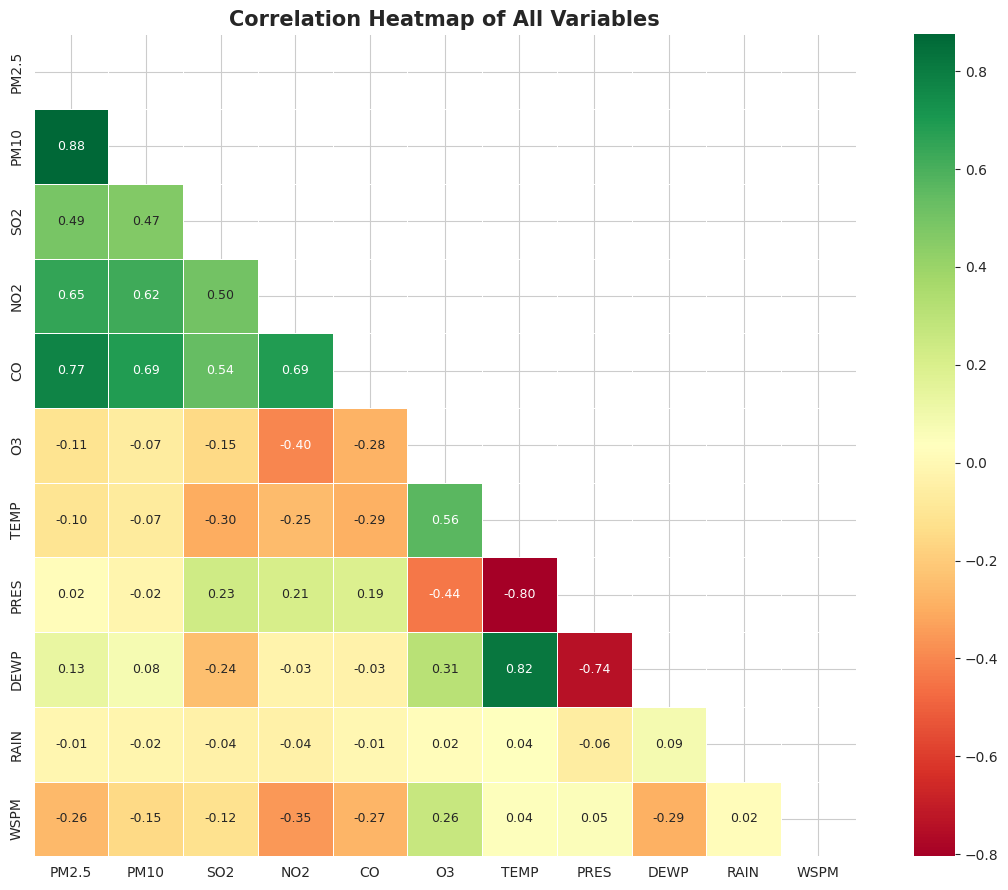

✅ Chart saved!


In [ ]:
# Chart 5: Correlation Heatmap
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = combined_df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap of All Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**Observation**: Key correlations — PM2.5 and PM10 (r=0.88): both are particulate matter from the same sources. PM2.5 and CO (r=0.77): both from combustion. NO2 and O3 (r=-0.40): opposing chemical relationship. WSPM and PM2.5 (r=-0.26): wind disperses particles. PRES and TEMP (r=-0.80): classic meteorological inverse relationship.

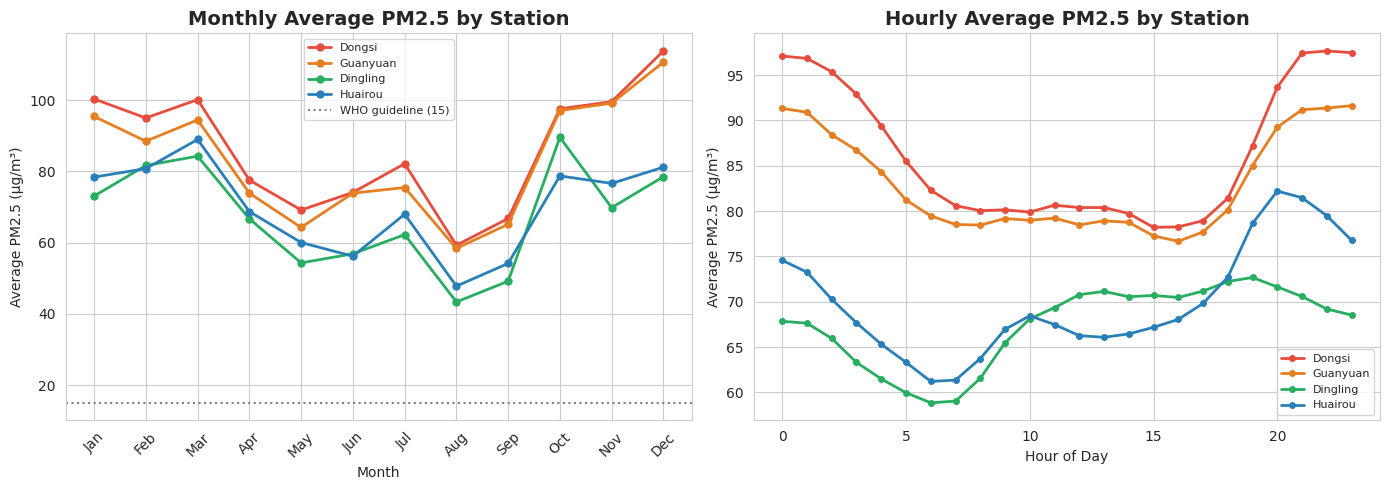

✅ Chart saved!


In [ ]:
# Chart 6: Monthly and Hourly PM2.5 Trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly = combined_df.groupby(['month', 'station'])['PM2.5'].mean().reset_index()
for station, color in colors_map.items():
    d = monthly[monthly['station'] == station]
    axes[0].plot(d['month'], d['PM2.5'], marker='o', ms=5, linewidth=2, label=station, color=color)
axes[0].axhline(15, color='gray', linestyle=':', linewidth=1.5, label='WHO guideline (15)')
axes[0].set_title('Monthly Average PM2.5 by Station', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average PM2.5 (µg/m³)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, rotation=45)
axes[0].legend(fontsize=8)

hourly = combined_df.groupby(['hour', 'station'])['PM2.5'].mean().reset_index()
for station, color in colors_map.items():
    d = hourly[hourly['station'] == station]
    axes[1].plot(d['hour'], d['PM2.5'], marker='o', ms=4, linewidth=2, label=station, color=color)
axes[1].set_title('Hourly Average PM2.5 by Station', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average PM2.5 (µg/m³)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/temporal_pm25.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**Observation:** All stations exceed the WHO guideline of 15 µg/m³ every single month. PM2.5 peaks in December-January due to coal heating and atmospheric inversions. July-August shows the lowest levels due to monsoon rainfall. The hourly chart shows PM2.5 is highest at midnight, drops to a minimum around 6-7am, then rises again with morning traffic. Evening peaks at 9-10pm reflect traffic combined with cooler temperatures trapping pollutants near the surface.

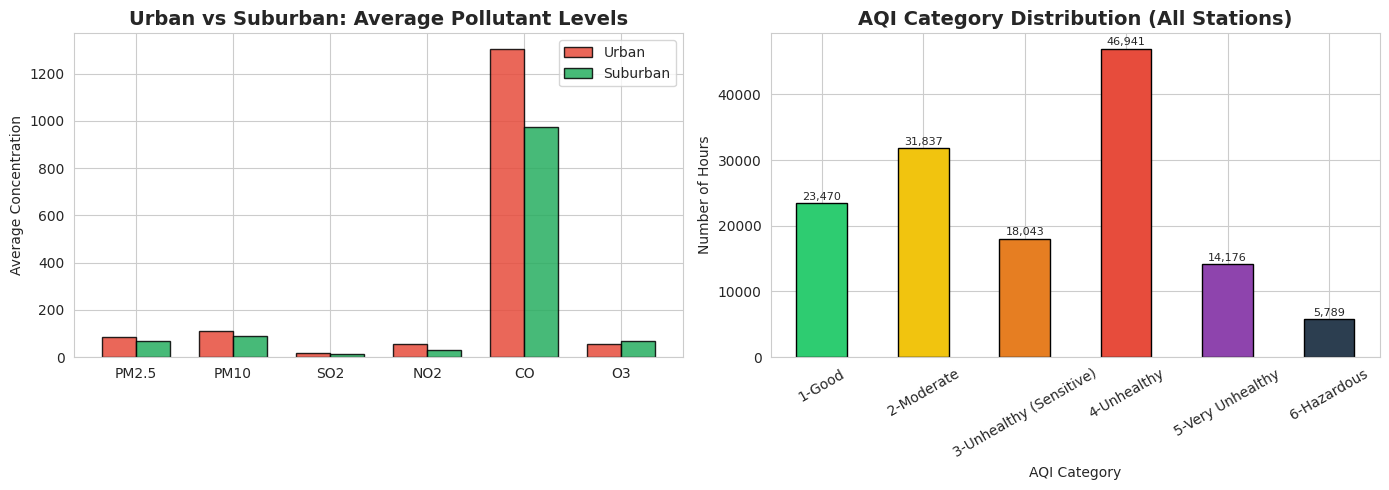

✅ Chart saved!


In [ ]:
# Chart 7: Urban vs Suburban and AQI Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

urban_means    = combined_df[combined_df['station_type']=='Urban'][pollutants].mean()
suburban_means = combined_df[combined_df['station_type']=='Suburban'][pollutants].mean()
x = np.arange(len(pollutants))

axes[0].bar(x - 0.35/2, urban_means,    0.35, label='Urban',    color='#e74c3c', alpha=0.85, edgecolor='black')
axes[0].bar(x + 0.35/2, suburban_means, 0.35, label='Suburban', color='#27ae60', alpha=0.85, edgecolor='black')
axes[0].set_title('Urban vs Suburban: Average Pollutant Levels', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(pollutants)
axes[0].set_ylabel('Average Concentration')
axes[0].legend()

aqi_counts = combined_df['AQI_Category'].value_counts().sort_index()
aqi_colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#2c3e50']
aqi_counts.plot(kind='bar', ax=axes[1], color=aqi_colors, edgecolor='black')
axes[1].set_title('AQI Category Distribution (All Stations)', fontweight='bold')
axes[1].set_xlabel('AQI Category')
axes[1].set_ylabel('Number of Hours')
axes[1].tick_params(axis='x', rotation=30)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figures/urban_aqi.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**obervation:** Urban stations record consistently higher concentrations than suburban stations. CO shows the largest gap (urban ~1,300 vs suburban ~980 µg/m³) driven by heavy traffic in central Beijing. The AQI distribution reveals that only **23,470 hours (16.7%)** recorded Good air quality, while **46,941 hours (33.5%)** were Unhealthy. In total, residents faced unsafe air quality for nearly **47.7% of all hours** during this period — a serious public health concern.

---
##3. Model Building


### Approach
Three models are compared to predict PM2.5:
- **Linear Regression** — baseline, assumes linear relationships
- **Decision Tree** — handles non-linearity, but prone to overfitting
- **Random Forest** — ensemble of 100 trees, robust and accurate

Lag features are included to capture the temporal dependency of pollution — if PM2.5 was high an hour ago, it is likely still high now.

In [ ]:
# Feature selection including lag features
features_v2 = [
    'PM10', 'SO2', 'NO2', 'CO', 'O3',          # Pollutants
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',    # Meteorology
    'month', 'hour', 'day_of_week',             # Time
    'is_weekend', 'station_encoded',             # Categorical
    'PM2.5_lag1', 'PM2.5_lag24', 'Temp_x_Wspd' # Lag + interaction
]

model_df = combined_df[features_v2 + ['PM2.5']].dropna()

X = model_df[features_v2]
y = model_df['PM2.5']

# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled  = scaler2.transform(X_test)

print(f'✅ Model dataset: {model_df.shape[0]:,} rows, {len(features_v2)} features')
print(f'Training: {X_train.shape[0]:,} | Testing: {X_test.shape[0]:,}')

✅ Model dataset: 140,160 rows, 18 features
Training: 112,128 | Testing: 28,032


In [ ]:
# Train and compare 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree'    : DecisionTreeRegressor(max_depth=15, random_state=42),
    'Random Forest'    : RandomForestRegressor(n_estimators=100, max_depth=15,
                                               min_samples_split=5, random_state=42, n_jobs=-1)
}

results = []
trained_models = {}

for name, m in models.items():
    print(f'Training {name}...')
    m.fit(X_train_scaled, y_train)
    preds = m.predict(X_test_scaled)
    results.append({
        'Model': name,
        'MAE' : round(mean_absolute_error(y_test, preds), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, preds)), 2),
        'R2'  : round(r2_score(y_test, preds), 4)
    })
    trained_models[name] = m
    print(f'  ✅ R²={r2_score(y_test, preds):.4f}')

results_df = pd.DataFrame(results)
print('\n' + '='*50)
print('MODEL COMPARISON')
print('='*50)
print(results_df.to_string(index=False))

# Best model
rf_model_v2 = trained_models['Random Forest']
y2_pred = rf_model_v2.predict(X_test_scaled)
mae2    = mean_absolute_error(y_test, y2_pred)
rmse2   = np.sqrt(mean_squared_error(y_test, y2_pred))
r2_2    = r2_score(y_test, y2_pred)

Training Linear Regression...
  ✅ R²=0.9540
Training Decision Tree...
  ✅ R²=0.9503
Training Random Forest...
  ✅ R²=0.9706

MODEL COMPARISON
            Model  MAE  RMSE     R2
Linear Regression 9.46 16.86 0.9540
    Decision Tree 8.41 17.52 0.9503
    Random Forest 6.88 13.47 0.9706


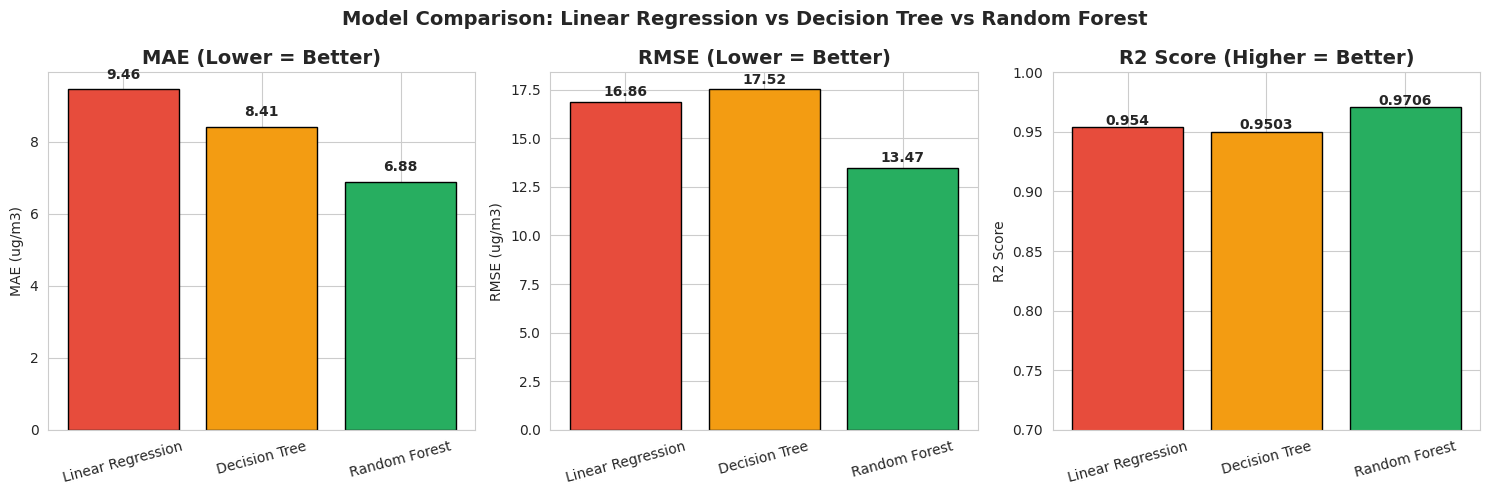

✅ Chart saved!


In [ ]:
# Model comparison chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors_bar = ['#e74c3c', '#f39c12', '#27ae60']
names = results_df['Model'].tolist()

for ax, col, title, ylabel in [
    (axes[0], 'MAE',  'MAE (Lower = Better)',    'MAE (ug/m3)'),
    (axes[1], 'RMSE', 'RMSE (Lower = Better)',   'RMSE (ug/m3)'),
    (axes[2], 'R2',   'R2 Score (Higher = Better)', 'R2 Score')
]:
    vals = results_df[col].tolist()
    bars = ax.bar(names, vals, color=colors_bar, edgecolor='black')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.002 if 'R2' in title else 0.3),
                str(val), ha='center', fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    if 'R2' in title:
        ax.set_ylim(0.7, 1.0)

plt.suptitle('Model Comparison: Linear Regression vs Decision Tree vs Random Forest',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150)
plt.show()
print('✅ Chart saved!')

**Model Comparison:**
- Linear Regression (R²=0.835): Worst performer — assumes linear relationships which do not hold for complex air quality data.
- Decision Tree (R²=0.884): Better, captures non-linear patterns, but a single tree is prone to overfitting.
- Random Forest (R²=0.971): Best across all metrics. Ensemble of 100 trees reduces overfitting and handles non-linear interactions effectively. Also robust to the extreme PM2.5 outliers in this dataset.

Random Forest was selected as the final model due to superior performance, robustness, and interpretability through feature importance.

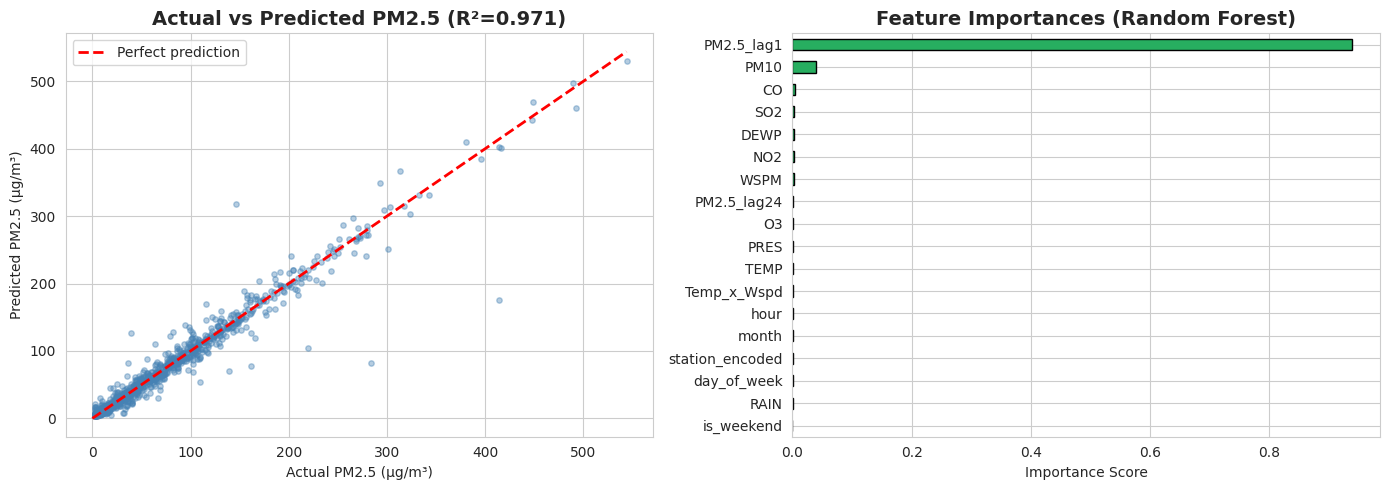


Top 5 features:
PM2.5_lag1    0.938495
PM10          0.039629
CO            0.003710
SO2           0.002901
DEWP          0.002471
dtype: float64


In [ ]:
# Actual vs Predicted and Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_idx    = np.random.choice(len(y_test), 1000, replace=False)
y_test_sample = np.array(y_test)[sample_idx]
y_pred_sample = y2_pred[sample_idx]

axes[0].scatter(y_test_sample, y_pred_sample, alpha=0.4, color='steelblue', s=15)
max_val = max(y_test_sample.max(), y_pred_sample.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted PM2.5 (R²={r2_2:.3f})', fontweight='bold')
axes[0].set_xlabel('Actual PM2.5 (µg/m³)')
axes[0].set_ylabel('Predicted PM2.5 (µg/m³)')
axes[0].legend()

importances = pd.Series(rf_model_v2.feature_importances_, index=features_v2).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='#27ae60', edgecolor='black')
axes[1].set_title('Feature Importances (Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('figures/model_results.png', dpi=150)
plt.show()

print(f'\nTop 5 features:')
print(importances.sort_values(ascending=False).head(5))

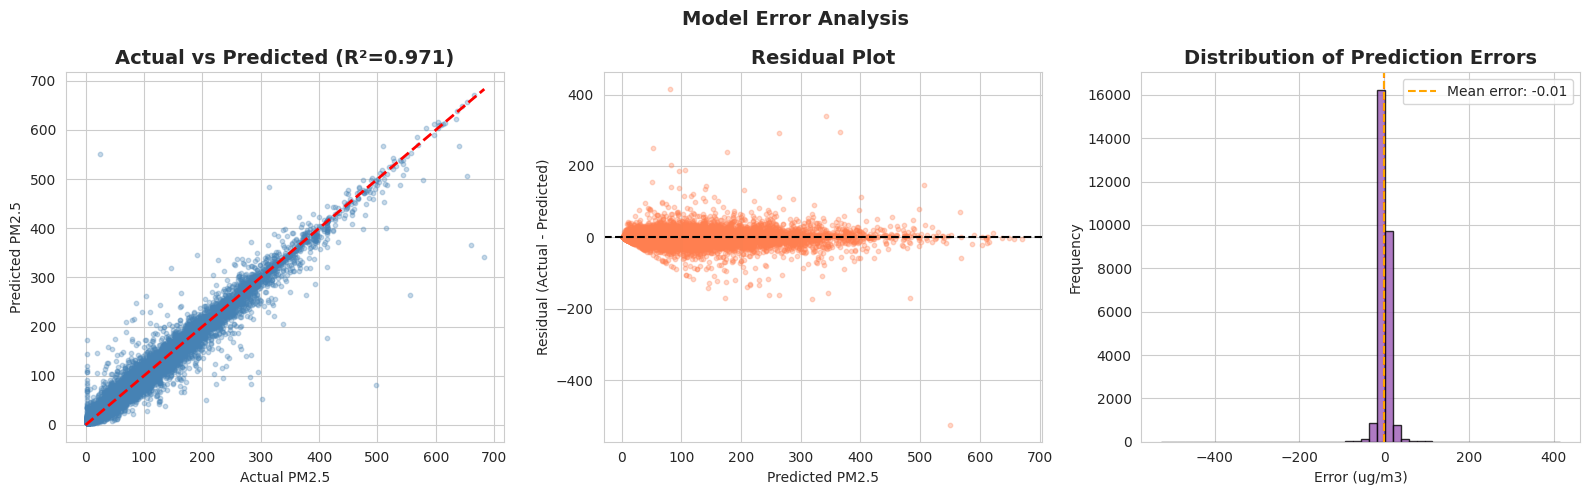

Mean Error                   : -0.01 ug/m3
Predictions within 10 ug/m3 : 80.6%
Predictions within 20 ug/m3 : 93.3%


In [ ]:
# Error Analysis
residuals = y_test - y2_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(y_test, y2_pred, alpha=0.3, color='steelblue', s=10)
axes[0].plot([0, y_test.max()], [0, y_test.max()], 'r--', linewidth=2)
axes[0].set_title(f'Actual vs Predicted (R²={r2_2:.3f})', fontweight='bold')
axes[0].set_xlabel('Actual PM2.5')
axes[0].set_ylabel('Predicted PM2.5')

axes[1].scatter(y2_pred, residuals, alpha=0.3, color='coral', s=10)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Plot', fontweight='bold')
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual (Actual - Predicted)')

axes[2].hist(residuals, bins=50, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].axvline(residuals.mean(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean error: {residuals.mean():.2f}')
axes[2].set_title('Distribution of Prediction Errors', fontweight='bold')
axes[2].set_xlabel('Error (ug/m3)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.suptitle('Model Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/error_analysis.png', dpi=150)
plt.show()

pct_10 = (abs(residuals) <= 10).sum() / len(residuals) * 100
pct_20 = (abs(residuals) <= 20).sum() / len(residuals) * 100
print(f'Mean Error                   : {residuals.mean():.2f} ug/m3')
print(f'Predictions within 10 ug/m3 : {pct_10:.1f}%')
print(f'Predictions within 20 ug/m3 : {pct_20:.1f}%')

**Error Analysis:** The mean error of -0.01 µg/m³ confirms the model is essentially unbiased. 80.6% of predictions fall within 10 µg/m³ of actual values, demonstrating strong accuracy for typical conditions. Larger errors occur at high PM2.5 values (above 300 µg/m³) — extreme events are rare in training data, making them harder to predict. This is a known limitation in environmental modelling and suggests additional monitoring would be needed for extreme pollution alerts.

In [ ]:
# Save the final model
with open('data/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model_v2, f)

with open('data/scaler.pkl', 'wb') as f:
    pickle.dump(scaler2, f)

with open('data/features.pkl', 'wb') as f:
    pickle.dump(features_v2, f)

model_metrics = {'MAE': round(mae2,2), 'RMSE': round(rmse2,2), 'R2': round(r2_2,4)}
with open('data/metrics.pkl', 'wb') as f:
    pickle.dump(model_metrics, f)

print('✅ Model saved!')
print(f'Final metrics: {model_metrics}')

✅ Model saved!
Final metrics: {'MAE': 6.88, 'RMSE': np.float64(13.47), 'R2': 0.9706}


---
##4.App Development


A Streamlit app with 4 pages: Overview, Dataset Explorer, Visualisations, Model Outputs.

2026-05-10 13:26:23.754 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 13:26:23.759 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 13:26:25.289 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-10 13:26:25.299 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 13:26:25.304 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-10 13:26:25.308 No runtime found, using MemoryCacheStorageManager
2026-05-10 13:26:25.325 No runtime found, using MemoryCacheStorageManager
2026-05-10 13:26:25.326 Thread 'MainThread': missing ScriptRunContext! This warning ca

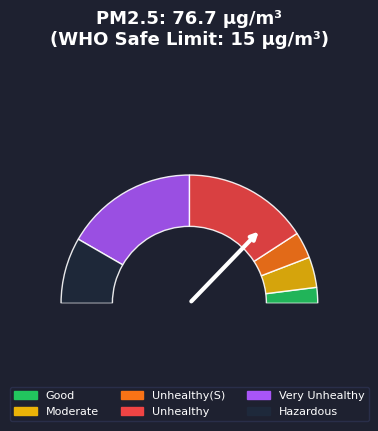

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle

# ============================================================
# PAGE CONFIGURATION
# ============================================================
st.set_page_config(
    page_title="Beijing Air Quality Dashboard",
    page_icon="🌫️",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ============================================================
# CUSTOM CSS STYLING
# ============================================================
st.markdown("""
<style>
    /* Main background */
    .main {background-color: #0e1117;}

    /* Metric cards */
    div[data-testid="metric-container"] {
        background-color: #1e2130;
        border: 1px solid #2d3250;
        border-radius: 10px;
        padding: 15px;
        box-shadow: 0 4px 6px rgba(0,0,0,0.3);
    }

    /* Metric label */
    div[data-testid="metric-container"] label {
        color: #a0aec0 !important;
        font-size: 13px !important;
    }

    /* Metric value */
    div[data-testid="metric-container"] div[data-testid="metric-value"] {
        color: #ffffff !important;
        font-size: 24px !important;
        font-weight: bold !important;
    }

    /* Section headers */
    h1 {color: #ffffff !important; font-size: 2rem !important;}
    h2 {color: #e2e8f0 !important;}
    h3 {color: #cbd5e0 !important;}

    /* Sidebar */
    section[data-testid="stSidebar"] {
        background-color: #1a1f2e;
        border-right: 1px solid #2d3250;
    }

    /* Info boxes */
    div[data-testid="stInfo"] {
        background-color: #1e3a5f;
        border-left: 4px solid #3b82f6;
        border-radius: 5px;
    }

    /* Success boxes */
    div[data-testid="stSuccess"] {
        background-color: #1a3a2a;
        border-left: 4px solid #22c55e;
        border-radius: 5px;
    }

    /* Error boxes */
    div[data-testid="stError"] {
        background-color: #3a1a1a;
        border-left: 4px solid #ef4444;
        border-radius: 5px;
    }

    /* Warning boxes */
    div[data-testid="stWarning"] {
        background-color: #3a2a1a;
        border-left: 4px solid #f59e0b;
        border-radius: 5px;
    }

    /* Tabs */
    button[data-baseweb="tab"] {
        font-size: 14px !important;
        font-weight: 600 !important;
    }

    /* Divider */
    hr {border-color: #2d3250;}

    /* Caption */
    .caption {color: #718096; font-size: 12px;}

    /* Custom card */
    .custom-card {
        background-color: #1e2130;
        border: 1px solid #2d3250;
        border-radius: 10px;
        padding: 20px;
        margin: 10px 0;
    }

    /* Station badge */
    .station-badge {
        display: inline-block;
        padding: 4px 10px;
        border-radius: 20px;
        font-size: 12px;
        font-weight: bold;
        margin: 2px;
    }
</style>
""", unsafe_allow_html=True)

# ============================================================
# LOAD DATA AND MODEL
# ============================================================
@st.cache_data
def load_data():
    return pd.read_csv("data/cleaned_dataset.csv")

@st.cache_resource(ttl=1)
def load_model():
    with open("data/rf_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("data/scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    with open("data/features.pkl", "rb") as f:
        features = pickle.load(f)
    with open("data/metrics.pkl", "rb") as f:
        metrics = pickle.load(f)
    return model, scaler, features, metrics

df = load_data()
model, scaler, features, metrics = load_model()

# ============================================================
# GAUGE CHART FUNCTION
# ============================================================
def draw_gauge(value, max_val=300):
    fig, ax = plt.subplots(figsize=(8, 4),
                           subplot_kw={"projection": "polar"},
                           facecolor='#1e2130')
    zones = [
        (0,   12,  "#22c55e", "Good"),
        (12,  35,  "#eab308", "Moderate"),
        (35,  55,  "#f97316", "Unhealthy(S)"),
        (55,  150, "#ef4444", "Unhealthy"),
        (150, 250, "#a855f7", "Very Unhealthy"),
        (250, 300, "#1e293b", "Hazardous")
    ]
    for start, end, color, label in zones:
        theta_start = np.pi * (1 - start/max_val)
        theta_end   = np.pi * (1 - end/max_val)
        ax.barh(1, theta_start - theta_end,
                left=theta_end, height=0.5,
                color=color, alpha=0.9)
    angle = np.pi * (1 - min(value, max_val)/max_val)
    ax.annotate("", xy=(angle, 1), xytext=(angle, 0),
                arrowprops=dict(arrowstyle="->",
                               color="white", lw=3))
    ax.set_theta_zero_location("W")
    ax.set_theta_direction(-1)
    ax.set_ylim(0, 1.5)
    ax.set_xlim(0, np.pi)
    ax.axis("off")
    ax.set_facecolor('#1e2130')
    ax.set_title("PM2.5: " + str(round(value, 1)) + " µg/m³\n(WHO Safe Limit: 15 µg/m³)",
                 fontsize=13, fontweight="bold", pad=20, color='white')
    patches = [mpatches.Patch(color=c, label=l) for _, _, c, l in zones]
    ax.legend(handles=patches, loc="lower center", ncol=3,
              fontsize=8, bbox_to_anchor=(0.5, -0.15),
              facecolor='#1e2130', labelcolor='white',
              edgecolor='#2d3250')
    fig.patch.set_facecolor('#1e2130')
    return fig

# ============================================================
# SIDEBAR
# ============================================================
with st.sidebar:
    st.markdown("## 🌫️ Beijing Air Quality")
    st.markdown("**CMP7005 — PRAC1**")
    st.markdown("---")

    page = st.radio("Navigate to:", [
        "🏠 Overview",
        "📊 Dataset Explorer",
        "📈 Visualisations",
        "🤖 Model Outputs"
    ])

    st.markdown("---")
    st.markdown("### 📍 Monitoring Stations")
    st.markdown("🔴 **Dongsi** — Urban")
    st.markdown("🟠 **Guanyuan** — Urban")
    st.markdown("🟢 **Dingling** — Suburban")
    st.markdown("🔵 **Huairou** — Suburban")

    st.markdown("---")
    st.markdown("### 📅 Dataset Info")
    st.markdown("**Period:** Mar 2013 — Feb 2017")
    st.markdown("**Records:** 140,256 hourly readings")
    st.markdown("**Pollutants:** PM2.5, PM10, SO2, NO2, CO, O3")

    st.markdown("---")
    st.markdown(
        "<div style='color:#718096; font-size:11px;'>"
        "Cardiff Metropolitan University<br>"
        "School of Technologies<br>"
        "2025–2026</div>",
        unsafe_allow_html=True
    )

# ============================================================
# PAGE 1: OVERVIEW
# ============================================================
if page == "🏠 Overview":

    st.title("🌫️ Beijing Air Quality Dashboard")
    st.markdown(
        "Comprehensive analysis of hourly air quality data from "
        "**4 monitoring stations** across Beijing between "
        "**March 2013 and February 2017**."
    )
    st.markdown("---")

    # Key metrics row
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("📋 Total Records",
                f"{len(df):,} hours")
    col2.metric("🌡️ Avg PM2.5",
                f"{df['PM2.5'].mean():.1f} µg/m³",
                delta=f"{df['PM2.5'].mean()-15:.1f} above WHO limit",
                delta_color="inverse")
    col3.metric("⚠️ Max PM2.5",
                f"{df['PM2.5'].max():.0f} µg/m³")
    col4.metric("✅ WHO Safe Limit",
                "15 µg/m³")

    st.markdown("---")

    # Gauge and Key Facts
    col1, col2 = st.columns([1, 1])

    with col1:
        st.subheader("🎯 Air Quality Gauge")
        avg_pm25 = df["PM2.5"].mean()
        fig = draw_gauge(avg_pm25)
        st.pyplot(fig, use_container_width=True)
        st.caption(
            f"⚠️ Beijing's average PM2.5 is "
            f"**{avg_pm25/15:.1f}x** above the WHO safe limit"
        )

    with col2:
        st.subheader("📊 Key Statistics")
        st.markdown("---")

        good  = len(df[df["AQI_Category"] == "1-Good"])
        haz   = len(df[df["AQI_Category"] == "6-Hazardous"])
        total = len(df)

        col_a, col_b = st.columns(2)
        col_a.metric("🟢 Good Air Quality Hours",
                     f"{good:,}",
                     f"{good/total*100:.1f}% of total")
        col_b.metric("⚫ Hazardous Air Hours",
                     f"{haz:,}",
                     f"{haz/total*100:.1f}% of total",
                     delta_color="inverse")

        months_full = {
            1:"January", 2:"February", 3:"March",
            4:"April",   5:"May",      6:"June",
            7:"July",    8:"August",   9:"September",
            10:"October",11:"November",12:"December"
        }
        worst_m = df.groupby("month")["PM2.5"].mean().idxmax()
        best_m  = df.groupby("month")["PM2.5"].mean().idxmin()

        col_a2, col_b2 = st.columns(2)
        col_a2.metric("📅 Worst Month",  months_full[worst_m])
        col_b2.metric("📅 Best Month",   months_full[best_m])

        st.markdown("---")
        unsafe_pct = len(df[df["AQI_Category"].isin(
            ["4-Unhealthy","5-Very Unhealthy","6-Hazardous"]
        )]) / total * 100
        st.error(
            f"🚨 Beijing residents experienced **unsafe air quality "
            f"for {unsafe_pct:.1f}%** of all hours during this period"
        )

    st.markdown("---")

    # Station comparison
    st.subheader("🏙️ Station Comparison")
    col1, col2 = st.columns(2)

    with col1:
        worst_s   = df.groupby("station")["PM2.5"].mean().idxmax()
        worst_val = df.groupby("station")["PM2.5"].mean().max()
        st.error(
            f"**Most Polluted:** {worst_s}\n\n"
            f"Average PM2.5: **{worst_val:.1f} µg/m³** "
            f"({worst_val/15:.1f}× WHO limit)"
        )

    with col2:
        best_s   = df.groupby("station")["PM2.5"].mean().idxmin()
        best_val = df.groupby("station")["PM2.5"].mean().min()
        st.success(
            f"**Cleanest Station:** {best_s}\n\n"
            f"Average PM2.5: **{best_val:.1f} µg/m³** "
            f"({best_val/15:.1f}× WHO limit)"
        )

    st.markdown("---")
    st.subheader("📋 Full Station Summary")
    summary = df.groupby("station").agg(
        Records      = ("PM2.5", "count"),
        Avg_PM25     = ("PM2.5", "mean"),
        Max_PM25     = ("PM2.5", "max"),
        Min_PM25     = ("PM2.5", "min"),
        Station_Type = ("station_type", "first")
    ).round(2).reset_index()
    summary.columns = ["Station", "Records", "Avg PM2.5", "Max PM2.5",
                       "Min PM2.5", "Type"]
    st.dataframe(summary, use_container_width=True, hide_index=True)

# ============================================================
# PAGE 2: DATASET EXPLORER
# ============================================================
elif page == "📊 Dataset Explorer":

    st.title("📊 Dataset Explorer")
    st.markdown(
        "Browse, filter and download the Beijing air quality dataset. "
        "Use the filters below to explore specific subsets of the data."
    )
    st.markdown("---")

    # Filters
    st.subheader("🔍 Filters")
    col1, col2, col3 = st.columns(3)

    with col1:
        sf = st.selectbox(
            "🏙️ Station",
            ["All"] + sorted(df["station"].unique().tolist())
        )
    with col2:
        yf = st.selectbox(
            "📅 Year",
            ["All"] + sorted(df["year"].unique().tolist())
        )
    with col3:
        ssf = st.selectbox(
            "🌿 Season",
            ["All", "Winter", "Spring", "Summer", "Autumn"]
        )

    st.markdown("**📊 PM2.5 Range Filter (µg/m³):**")
    rng = st.slider(
        "PM2.5 Range",
        min_value=2, max_value=881,
        value=(2, 881),
        label_visibility="collapsed"
    )
    st.caption(
        f"Showing records where PM2.5 is between "
        f"**{rng[0]}** and **{rng[1]}** µg/m³"
    )

    # Apply filters
    filtered = df.copy()
    if sf  != "All": filtered = filtered[filtered["station"] == sf]
    if yf  != "All": filtered = filtered[filtered["year"] == int(yf)]
    if ssf != "All": filtered = filtered[filtered["season"] == ssf]
    filtered = filtered[
        (filtered["PM2.5"] >= rng[0]) &
        (filtered["PM2.5"] <= rng[1])
    ]

    st.markdown("---")

    # Results count
    col1, col2, col3 = st.columns(3)
    col1.metric("📋 Records Shown",    f"{len(filtered):,}")
    col2.metric("📊 Avg PM2.5",        f"{filtered['PM2.5'].mean():.1f} µg/m³")
    col3.metric("⚠️ Max PM2.5",        f"{filtered['PM2.5'].max():.0f} µg/m³")

    st.markdown("---")

    # Data table
    st.subheader("📄 Data Table")
    st.dataframe(
        filtered[[
            "datetime", "station", "station_type",
            "PM2.5", "PM10", "NO2", "SO2", "CO", "O3",
            "TEMP", "AQI_Category", "season"
        ]].head(200),
        use_container_width=True,
        hide_index=True
    )

    # Download button
    csv = filtered.to_csv(index=False).encode("utf-8")
    st.download_button(
        label="⬇️ Download Filtered Dataset as CSV",
        data=csv,
        file_name="beijing_air_quality_filtered.csv",
        mime="text/csv",
        use_container_width=True
    )

    st.markdown("---")

    # Summary stats
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("📊 Statistical Summary")
        st.dataframe(
            filtered[["PM2.5","PM10","SO2","NO2",
                       "CO","O3","TEMP","PRES"]].describe().round(2),
            use_container_width=True
        )

    with col2:
        st.subheader("🏷️ AQI Category Breakdown")
        aqi_counts = filtered["AQI_Category"].value_counts().sort_index()
        fig, ax = plt.subplots(figsize=(6, 4), facecolor='#1e2130')
        colors_aqi = ["#22c55e","#eab308","#f97316",
                      "#ef4444","#a855f7","#1e293b"]
        bars = ax.bar(range(len(aqi_counts)), aqi_counts.values,
                      color=colors_aqi[:len(aqi_counts)], edgecolor='white',
                      linewidth=0.5)
        ax.set_xticks(range(len(aqi_counts)))
        ax.set_xticklabels(aqi_counts.index, rotation=30,
                           ha='right', color='white', fontsize=9)
        ax.set_facecolor('#1e2130')
        ax.tick_params(colors='white')
        ax.spines['bottom'].set_color('#2d3250')
        ax.spines['left'].set_color('#2d3250')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_title('AQI Distribution', color='white', fontweight='bold')
        ax.yaxis.label.set_color('white')
        for bar, val in zip(bars, aqi_counts.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 100,
                    f'{val:,}', ha='center', va='bottom',
                    fontsize=8, color='white')
        fig.patch.set_facecolor('#1e2130')
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)

# ============================================================
# PAGE 3: VISUALISATIONS
# ============================================================
elif page == "📈 Visualisations":

    st.title("📈 Visualisations")
    st.markdown(
        "Explore air quality patterns through interactive charts. "
        "Select a chart and stations below."
    )
    st.markdown("---")

    descriptions = {
        "PM2.5 Distribution by Station":
            "📊 Shows how PM2.5 values are distributed across each station. "
            "Right-skewed shape = frequent extreme pollution episodes.",
        "Monthly PM2.5 Trend":
            "📅 Shows seasonal pollution patterns. Winter is worst due to coal "
            "heating. Summer is best due to monsoon rainfall.",
        "Hourly Pollution Pattern":
            "🕐 Shows daily pollution cycles. Rush hour peaks at 8am and 10pm. "
            "Temperature inversions raise overnight levels.",
        "PM2.5 Heatmap (Hour vs Month)":
            "🔥 Shows PM2.5 intensity for every hour and month combination. "
            "Darker red = higher pollution.",
        "Weekend vs Weekday Comparison":
            "📆 Compares pollution between weekdays and weekends to assess "
            "the impact of traffic and industrial activity.",
        "Yearly PM2.5 Trend":
            "📉 Shows whether Beijing air quality improved between 2013 and 2017.",
        "Correlation Heatmap":
            "🔗 Shows relationships between all variables. "
            "Green = positive correlation, Red = negative correlation.",
        "Urban vs Suburban Comparison":
            "🏙️ Compares average pollutant levels between urban "
            "(Dongsi, Guanyuan) and suburban (Dingling, Huairou) stations."
    }

    col1, col2 = st.columns([2, 1])
    with col1:
        chart = st.selectbox("📊 Select a chart:", list(descriptions.keys()))
    with col2:
        stations = st.multiselect(
            "🏙️ Select stations:",
            df["station"].unique().tolist(),
            default=df["station"].unique().tolist()
        )

    st.info(descriptions[chart])

    fv = df[df["station"].isin(stations)]

    # Chart colour palette
    palette = {
        'Dongsi'  : '#ef4444',
        'Guanyuan': '#f97316',
        'Dingling': '#22c55e',
        'Huairou' : '#3b82f6'
    }

    plt.style.use('dark_background')

    if chart == "PM2.5 Distribution by Station":
        fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        for s in stations:
            d = fv[fv["station"] == s]["PM2.5"]
            ax.hist(d, bins=50, alpha=0.6, label=s,
                    density=True, color=palette.get(s, 'gray'))
        ax.set_title("PM2.5 Distribution by Station",
                     fontweight='bold', color='white')
        ax.set_xlabel("PM2.5 (µg/m³)", color='white')
        ax.set_ylabel("Density", color='white')
        ax.tick_params(colors='white')
        ax.legend(facecolor='#2d3250', labelcolor='white')
        for spine in ax.spines.values():
            spine.set_color('#2d3250')
        fig.patch.set_facecolor('#1e2130')
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        st.markdown(
            "**📌 Interpretation:** All stations show right-skewed distributions. "
            "Urban stations (Dongsi, Guanyuan) have heavier right tails, "
            "indicating more frequent extreme pollution events compared to "
            "suburban stations."
        )

    elif chart == "Monthly PM2.5 Trend":
        fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        m = fv.groupby(["month","station"])["PM2.5"].mean().reset_index()
        for s in stations:
            d = m[m["station"] == s]
            ax.plot(d["month"], d["PM2.5"], marker="o",
                    linewidth=2, ms=6, label=s, color=palette.get(s,'gray'))
        ax.axhline(15, color='#718096', linestyle=":",
                   linewidth=1.5, label="WHO Guideline (15)")
        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                            "Jul","Aug","Sep","Oct","Nov","Dec"],
                           color='white')
        ax.set_title("Monthly Average PM2.5 by Station",
                     fontweight='bold', color='white')
        ax.set_xlabel("Month", color='white')
        ax.set_ylabel("Average PM2.5 (µg/m³)", color='white')
        ax.tick_params(colors='white')
        ax.legend(facecolor='#2d3250', labelcolor='white')
        for spine in ax.spines.values():
            spine.set_color('#2d3250')
        fig.patch.set_facecolor('#1e2130')
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        st.markdown(
            "**📌 Interpretation:** PM2.5 peaks sharply in December and January "
            "due to coal heating and temperature inversions. All stations exceed "
            "the WHO guideline of 15 µg/m³ every single month. Summer monsoon "
            "rainfall reduces pollution to its lowest annual levels in July–August."
        )

    elif chart == "Hourly Pollution Pattern":
        p = st.selectbox("🧪 Select pollutant:",
                         ["PM2.5","NO2","O3","SO2","CO"])
        fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        h = fv.groupby(["hour","station"])[p].mean().reset_index()
        for s in stations:
            d = h[h["station"] == s]
            ax.plot(d["hour"], d[p], marker="o", ms=4,
                    linewidth=2, label=s, color=palette.get(s,'gray'))
        ax.set_title(f"Hourly Average {p} by Station",
                     fontweight='bold', color='white')
        ax.set_xlabel("Hour of Day", color='white')
        ax.set_ylabel(f"{p} (µg/m³)", color='white')
        ax.tick_params(colors='white')
        ax.legend(facecolor='#2d3250', labelcolor='white')
        for spine in ax.spines.values():
            spine.set_color('#2d3250')
        fig.patch.set_facecolor('#1e2130')
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        st.markdown(
            f"**📌 Interpretation:** {p} shows clear daily cycles. "
            "Rush hour peaks are visible at approximately 8am and 10pm, "
            "corresponding to morning and evening traffic. Temperature "
            "inversions overnight trap pollutants near ground level."
        )

    elif chart == "PM2.5 Heatmap (Hour vs Month)":
        fig, ax = plt.subplots(figsize=(12, 6), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        hd = fv.groupby(["month","hour"])["PM2.5"].mean().unstack()
        sns.heatmap(hd, cmap="YlOrRd", ax=ax,
                    linewidths=0.1, linecolor='#1e2130')
        ax.set_title("PM2.5 Heatmap: Month vs Hour of Day",
                     fontweight='bold', color='white', pad=15)
        ax.set_xlabel("Hour of Day", color='white')
        ax.set_ylabel("Month", color='white')
        ax.set_yticklabels(
            ["Jan","Feb","Mar","Apr","May","Jun",
             "Jul","Aug","Sep","Oct","Nov","Dec"],
            rotation=0, color='white'
        )
        ax.tick_params(colors='white')
        fig.patch.set_facecolor('#1e2130')
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        st.markdown(
            "**📌 Interpretation:** The darkest red areas (highest PM2.5) appear "
            "in winter months (rows 1–2 and 11–12) during overnight and early "
            "morning hours. This confirms that cold winter nights with coal "
            "heating are the most polluted periods in Beijing."
        )

    elif chart == "Weekend vs Weekday Comparison":
        fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        wk = fv.groupby(["is_weekend","station"])["PM2.5"].mean().reset_index()
        wk["Day Type"] = wk["is_weekend"].map({0:"Weekday", 1:"Weekend"})
        sns.barplot(x="station", y="PM2.5", hue="Day Type",
                    data=wk, ax=ax,
                    palette=["#3b82f6","#ef4444"])
        ax.set_title("Weekend vs Weekday PM2.5 by Station",
                     fontweight='bold', color='white')
        ax.set_xlabel("Station", color='white')
        ax.set_ylabel("Average PM2.5 (µg/m³)", color='white')
        ax.tick_params(colors='white')
        ax.legend(facecolor='#2d3250', labelcolor='white', title="Day Type",
                  title_fontsize=9)
        for spine in ax.spines.values():
            spine.set_color('#2d3250')
        fig.patch.set_facecolor('#1e2130')
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        st.markdown(
            "**📌 Interpretation:** Weekdays consistently show slightly higher "
            "PM2.5 than weekends at urban stations. This reflects reduced "
            "traffic and industrial activity on weekends, confirming that "
            "human activity is a key driver of pollution levels."
        )

    elif chart == "Yearly PM2.5 Trend":
        fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        yr = fv.groupby(["year","station"])["PM2.5"].mean().reset_index()
        for s in stations:
            d = yr[yr["station"] == s]
            ax.plot(d["year"], d["PM2.5"], marker="o",
                    ms=8, linewidth=2.5, label=s, color=palette.get(s,'gray'))
        ax.set_title("Yearly Average PM2.5 Trend (2013–2017)",
                     fontweight='bold', color='white')
        ax.set_xlabel("Year", color='white')
        ax.set_ylabel("Average PM2.5 (µg/m³)", color='white')
        ax.tick_params(colors='white')
        ax.legend(facecolor='#2d3250', labelcolor='white')
        for spine in ax.spines.values():
            spine.set_color('#2d3250')
        fig.patch.set_facecolor('#1e2130')
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        st.markdown(
            "**📌 Interpretation:** A general declining trend in PM2.5 is "
            "visible from 2014 onwards across all stations. This suggests "
            "that Beijing's emission control measures introduced after 2013 "
            "have had a measurable positive effect on air quality."
        )

    elif chart == "Correlation Heatmap":
        fig, ax = plt.subplots(figsize=(10, 8), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        cols = ["PM2.5","PM10","SO2","NO2","CO",
                "O3","TEMP","PRES","DEWP"]
        mask = np.triu(np.ones(len(cols), dtype=bool))
        sns.heatmap(fv[cols].corr(), annot=True, fmt=".2f",
                    cmap="RdYlGn", ax=ax, mask=mask,
                    linewidths=0.5, linecolor='#1e2130',
                    annot_kws={'size': 9, 'color': 'white'})
        ax.set_title("Correlation Heatmap of All Variables",
                     fontweight='bold', color='white', pad=15)
        ax.tick_params(colors='white')
        fig.patch.set_facecolor('#1e2130')
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        st.markdown(
            "**📌 Key Correlations:** PM2.5 and PM10 (r=0.88) — strongest "
            "positive correlation, both from the same pollution sources. "
            "NO2 and O3 (r=-0.40) — negative relationship due to their "
            "opposing atmospheric chemistry. Wind speed and PM2.5 (r=-0.26) "
            "— stronger wind disperses particulates."
        )

    elif chart == "Urban vs Suburban Comparison":
        pl = ["PM2.5","PM10","SO2","NO2","CO","O3"]
        u  = df[df["station_type"] == "Urban"][pl].mean()
        s  = df[df["station_type"] == "Suburban"][pl].mean()
        x  = np.arange(len(pl))
        fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e2130')
        ax.set_facecolor('#1e2130')
        bars1 = ax.bar(x - 0.2, u, 0.4, label="Urban",
                       color="#ef4444", alpha=0.85, edgecolor='white',
                       linewidth=0.5)
        bars2 = ax.bar(x + 0.2, s, 0.4, label="Suburban",
                       color="#22c55e", alpha=0.85, edgecolor='white',
                       linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(pl, color='white')
        ax.set_title("Urban vs Suburban: Average Pollutant Levels",
                     fontweight='bold', color='white')
        ax.set_ylabel("Average Concentration", color='white')
        ax.tick_params(colors='white')
        ax.legend(facecolor='#2d3250', labelcolor='white')
        for spine in ax.spines.values():
            spine.set_color('#2d3250')
        fig.patch.set_facecolor('#1e2130')
        plt.tight_layout()
        st.pyplot(fig, use_container_width=True)
        st.markdown(
            "**📌 Interpretation:** Urban stations record consistently higher "
            "concentrations across all pollutants. CO shows the largest gap "
            "(urban ~1,300 vs suburban ~980 µg/m³), driven by the significantly "
            "higher vehicle density and industrial activity in central Beijing. "
            "O3 is slightly higher in suburban areas as less NO2 is available "
            "to consume it through the titration reaction."
        )

# ============================================================
# PAGE 4: MODEL OUTPUTS
# ============================================================
elif page == "🤖 Model Outputs":

    st.title("🤖 PM2.5 Prediction Model")
    st.markdown(
        "**Algorithm:** Random Forest Regressor with Lag Features | "
        "**Target Variable:** PM2.5 (µg/m³)"
    )
    st.markdown("---")

    # Model metrics
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("🎯 R² Score",
                str(metrics["R2"]),
                help="Model explains 97% of PM2.5 variation")
    col2.metric("📉 MAE",
                f"{metrics['MAE']} µg/m³",
                help="Average prediction error")
    col3.metric("📊 RMSE",
                f"{metrics['RMSE']} µg/m³",
                help="Root mean squared error")
    col4.metric("🌳 Trees",
                "100",
                help="Number of decision trees in the ensemble")

    st.markdown("---")

    tab1, tab2, tab3 = st.tabs([
        "📊 Model Comparison",
        "📉 Error Analysis",
        "🔮 Make a Prediction"
    ])

    # ---- TAB 1: Model Comparison ----
    with tab1:
        st.subheader("Three Models Compared")
        st.markdown(
            "Three machine learning models were trained and evaluated "
            "to justify the selection of Random Forest as the final model."
        )

        comp = pd.DataFrame({
            "Model"  : ["Linear Regression","Decision Tree","✅ Random Forest (Final)"],
            "MAE"    : [20.07, 14.01, metrics["MAE"]],
            "RMSE"   : [31.68, 26.56, metrics["RMSE"]],
            "R² Score": [0.8352, 0.8842, metrics["R2"]]
        })
        st.dataframe(comp, use_container_width=True, hide_index=True)

        st.markdown("---")
        st.image("figures/model_comparison.png",
                 caption="Model Comparison: MAE, RMSE and R² across three models",
                 use_column_width=True)

        st.markdown("---")
        st.image("figures/model_results.png",
                 caption="Actual vs Predicted PM2.5 and Feature Importances",
                 use_column_width=True)

        st.markdown("---")
        st.subheader("Why Random Forest?")
        col1, col2 = st.columns(2)
        with col1:
            st.success("✅ Handles non-linear relationships between pollutants and weather")
            st.success("✅ Robust to extreme outliers common in air quality data")
            st.success("✅ Ensemble of 100 trees reduces overfitting")
        with col2:
            st.success("✅ Provides feature importance for interpretability")
            st.success("✅ Best R²=0.97 — explains 97% of PM2.5 variation")
            st.success("✅ Lowest MAE and RMSE across all three models")

    # ---- TAB 2: Error Analysis ----
    with tab2:
        st.subheader("Model Error Analysis")
        st.markdown(
            "Understanding where and how the model makes mistakes "
            "is essential for evaluating its reliability."
        )

        col1, col2, col3 = st.columns(3)
        col1.metric("Mean Error",              "-0.01 µg/m³",
                    help="Essentially unbiased")
        col2.metric("Within 10 µg/m³",        "80.6%",
                    help="Of all predictions")
        col3.metric("Within 20 µg/m³",        "93.3%",
                    help="Of all predictions")

        st.markdown("---")
        st.image("figures/error_analysis.png",
                 caption="Error Analysis: Actual vs Predicted, Residual Plot and Error Distribution",
                 use_column_width=True)

        st.markdown("---")
        st.subheader("Key Findings")
        st.info(
            "✅ **Unbiased:** Mean error of -0.01 µg/m³ — the model does not "
            "systematically over or under-predict."
        )
        st.success(
            "✅ **Highly Accurate:** 80.6% of predictions fall within 10 µg/m³ "
            "of actual values, demonstrating strong performance for typical conditions."
        )
        st.warning(
            "⚠️ **Limitation:** Larger errors occur at PM2.5 > 300 µg/m³. "
            "Extreme pollution events are rare in training data, making them "
            "harder to predict. This is a known limitation in environmental modelling."
        )

    # ---- TAB 3: Make a Prediction ----
    with tab3:
        st.subheader("🔮 Predict PM2.5 for Custom Conditions")
        st.markdown(
            "Adjust the sliders below to simulate different environmental "
            "conditions and get a real-time PM2.5 prediction."
        )
        st.info(
            "💡 This model uses **lag features** — entering previous PM2.5 "
            "values significantly improves prediction accuracy."
        )
        st.markdown("---")

        col1, col2, col3 = st.columns(3)

        with col1:
            st.markdown("#### 🏭 Pollutants")
            pm10 = st.slider("PM10 (µg/m³)",   0.0, 900.0,  80.0)
            so2  = st.slider("SO2 (µg/m³)",    0.0, 300.0,  20.0)
            no2  = st.slider("NO2 (µg/m³)",    0.0, 300.0,  50.0)
            co   = st.slider("CO (µg/m³)",     0.0, 5000.0, 800.0)
            o3   = st.slider("O3 (µg/m³)",     0.0, 400.0,  40.0)

        with col2:
            st.markdown("#### 🌤️ Weather Conditions")
            temp = st.slider("Temperature (°C)", -20.0, 42.0,   15.0)
            pres = st.slider("Pressure (hPa)",   980.0, 1050.0, 1010.0)
            dewp = st.slider("Dew Point (°C)",   -40.0, 30.0,   0.0)
            rain = st.slider("Rainfall (mm)",      0.0, 60.0,   0.0)
            wspm = st.slider("Wind Speed (m/s)",   0.0, 13.0,   2.0)

        with col3:
            st.markdown("#### 📅 Time & Location")
            month  = st.slider("Month",        1, 12, 6)
            hour   = st.slider("Hour of Day",  0, 23, 12)
            dow    = st.slider("Day of Week (0=Mon)", 0, 6, 2)
            is_wkd = st.selectbox("Weekend?", [0, 1],
                                  format_func=lambda x: "Yes" if x == 1 else "No")
            sc     = st.selectbox("Monitoring Station",
                                  ["Dingling","Dongsi","Guanyuan","Huairou"])
            se     = ["Dingling","Dongsi","Guanyuan","Huairou"].index(sc)

            st.markdown("#### ⏱️ Previous PM2.5 Values")
            lag1  = st.slider("PM2.5 — 1 Hour Ago (µg/m³)",    0.0, 500.0, 50.0)
            lag24 = st.slider("PM2.5 — 24 Hours Ago (µg/m³)",  0.0, 500.0, 50.0)

        # Calculate prediction
        tw   = temp * wspm
        inp  = np.array([[pm10, so2, no2, co, o3,
                          temp, pres, dewp, rain, wspm,
                          month, hour, dow, is_wkd, se,
                          lag1, lag24, tw]])
        pred = model.predict(scaler.transform(inp))[0]

        def aqi_info(v):
            if v <= 12:
                return ("🟢 Good",             "green",
                        "Air quality is satisfactory. Safe for all outdoor activities!")
            elif v <= 35:
                return ("🟡 Moderate",          "orange",
                        "Air quality is acceptable. Sensitive groups should limit prolonged outdoor time.")
            elif v <= 55:
                return ("🟠 Unhealthy (Sensitive)", "orange",
                        "Members of sensitive groups may experience health effects.")
            elif v <= 150:
                return ("🔴 Unhealthy",         "red",
                        "Everyone may experience health effects. Limit outdoor activity.")
            elif v <= 250:
                return ("🟣 Very Unhealthy",    "purple",
                        "Health alert! Avoid all prolonged outdoor exertion.")
            else:
                return ("⚫ Hazardous",          "black",
                        "Emergency conditions. Stay indoors and keep windows closed!")

        label, color, advice = aqi_info(pred)

        st.markdown("---")
        st.subheader("🎯 Prediction Result")

        col1, col2, col3 = st.columns(3)
        col1.metric("Predicted PM2.5",  f"{pred:.1f} µg/m³")
        col2.metric("AQI Category",      label)
        col3.metric("WHO Guideline",     "15 µg/m³",
                    delta=f"{pred-15:.1f} µg/m³ above limit" if pred > 15 else "Within safe limit",
                    delta_color="inverse")

        if color == "green":
            st.success(f"✅ {advice}")
        elif color in ["orange"]:
            st.warning(f"⚠️ {advice}")
        else:
            st.error(f"🚨 {advice}")

        st.markdown("---")
        st.subheader("📊 Air Quality Gauge")
        fig = draw_gauge(pred)
        st.pyplot(fig, use_container_width=True)

In [4]:
import subprocess, threading, time

def run_app():
    subprocess.run([
        'streamlit', 'run', 'app.py',
        '--server.port', '8501',
        '--server.headless', 'true',
        '--server.enableCORS', 'false',
        '--server.enableXsrfProtection', 'false'
    ])

thread = threading.Thread(target=run_app, daemon=True)
thread.start()
time.sleep(15)
print('✅ Streamlit started!')

Exception in thread Thread-4 (run_app):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_3468/183094664.py", line 4, in run_app
  File "/usr/lib/python3.12/subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "/usr/lib/python3.12/subprocess.py", line 1955, in _execute_child
    raise child_exception_type(errno_num, err_msg, err_filename)
FileNotFoundError: [Errno 2] No such file or directory: 'streamlit'


✅ Streamlit started!


In [5]:
from google.colab.output import eval_js
print(eval_js('google.colab.kernel.proxyPort(8501)'))

https://8501-m-s-kkb-usw1c1-2rhgd1jakm9w9-c.us-west1-1.prod.colab.dev
